# WILDCARD v6.9.13 Strategy and Fun Lab

## tl;dr

- **Best opening rule:** on the guided first run, exhaustive enumeration clears the 90-point Heat 1 target in one play on 80.4% of initial deals, versus 41.0% with no boost. Pair-or-better is the practical floor; High Card is normally a discard signal.
- **Starter result:** **Guided first run: Copper Chip + Pair Polisher** produced the deepest average run (9.87 Heats). The highest observed Heat-12 clear rate was **Royal Retainer** at 1.7%, but the paired confidence intervals decide whether that lead is meaningful.
- **Full-run strategy:** **Adaptive greedy** and **Flush engine** are effectively tied at 23.3% and 22.5% (paired exact p=0.646). Strength is reviewed alongside hand entropy, build identity, Joker activity, dramatic clears and failure walls rather than collapsed into one “fun score.”
- **Scope:** 50,000 paired opening deals and 19,000 complete 12-Heat runs from the exact v6.9.13 source hash `499c1ebe75a5346e7fe3c06cf0b0328cc29e32e90d62a77b237071ffeaa2bab9`.


## Context & Methods

This notebook supports three product decisions: what a player should do with the first nine cards, which starter boost is strongest in the starter collection, and which full-run build policy is strongest without making play repetitive or opaque.

### Key Assumptions

- “Best opening” means the highest immediate legal score among useful one-to-five-card plays. It does **not** prove that playing immediately is better than discarding.
- Starter comparisons use the same adaptive shop bot, paired run seeds and the real ten-Joker starter shop pool. Account-coin starter prices are descriptive; they do not change run coins.
- Strategy comparisons use all 57 Jokers in shops, the same exhaustive immediate-score card selector and **no free start boost**. Differences mainly measure shop/build priorities plus Pair/Flush discard priorities.
- Fun is represented by separate proxies: hand variety, build identity, Joker activity, dramatic close clears, affordable shop choice and failure hazards. A bot cannot measure enjoyment.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
DECISION_PATH = ROOT / "docs" / "release" / "wildcard-v6.9.13-decision-lab-results.json"
STRATEGY_PATH = ROOT / "docs" / "release" / "wildcard-v6.9.13-strategy-results.json"

decision = json.loads(DECISION_PATH.read_text(encoding="utf-8"))
strategy = json.loads(STRATEGY_PATH.read_text(encoding="utf-8"))

assert decision["version"] == "6.9.13"
assert strategy["version"] == "6.9.13"
assert decision["sourceSha256"] == strategy["sourceSha256"]
assert not decision["dataFailures"] and not decision["hookErrors"] and not decision["invariantFailures"]
assert not strategy["dataFailures"] and not strategy["hookErrors"] and not strategy["invariantFailures"]

SOURCE_SHA = decision["sourceSha256"]
TOTAL_FULL_RUNS = decision["counts"]["fullRuns"] + strategy["counts"]["fullRuns"]
print(f"Source SHA-256: {SOURCE_SHA}")
print(f"Opening deals: {decision['counts']['openingDeals']:,}")
print(f"Complete runs: {TOTAL_FULL_RUNS:,}")

Source SHA-256: 499c1ebe75a5346e7fe3c06cf0b0328cc29e32e90d62a77b237071ffeaa2bab9
Opening deals: 50,000
Complete runs: 19,000


## Data

In [2]:
opening = pd.DataFrame(decision["opening"]["summaries"])
starters = pd.DataFrame([
    {
        "id": row["id"], "starter": row["name"], "cost": row["cost"],
        "win_rate": row["winRate"], "ci_low": row["winRate95"]["low"], "ci_high": row["winRate95"]["high"],
        "avg_cleared": row["avgCleared"], "reach_h9": row["reachByHeat"]["9"],
        "reach_h12": row["reachByHeat"]["12"], "boss_hazard": row["fun"]["bossHazard"],
        "entropy": row["fun"]["handEntropy"], "dominant_share": row["fun"]["dominantHandShare"],
        "active_play_rate": row["fun"]["jokerActivePlayRate"],
        "triggers_per_play": row["fun"]["jokerTriggerEventsPerPlay"],
        "notable_play_rate": row["fun"]["notablePlayRate"],
        "any_callout_play_rate": row["fun"]["anyCalloutPlayRate"],
        "final_play_clears": row["fun"]["finalPlayClearRate"],
        "close_clears": row["fun"]["closeClearRate"],
        "build_distance": row["fun"]["meanBuildJaccardDistance"],
    }
    for row in decision["starters"]["summaries"]
])
strategies = pd.DataFrame([
    {
        "id": row["id"], "strategy": row["name"], "win_rate": row["winRate"],
        "ci_low": row["winRate95"]["low"], "ci_high": row["winRate95"]["high"],
        "avg_cleared": row["avgCleared"], "reach_h9": row["reachH9"], "reach_h11": row["reachH11"],
        "entropy": row["fun"]["handEntropy"], "dominant_hand": row["fun"]["dominantHand"],
        "dominant_share": row["fun"]["dominantHandShare"],
        "active_play_rate": row["fun"]["jokerActivePlayRate"],
        "triggers_per_play": row["fun"]["jokerTriggerEventsPerPlay"],
        "notable_play_rate": row["fun"]["notablePlayRate"],
        "any_callout_play_rate": row["fun"]["anyCalloutPlayRate"],
        "final_play_clears": row["fun"]["finalPlayClearRate"],
        "close_clears": row["fun"]["closeClearRate"],
        "comeback_clears": row["fun"]["comebackClearRate"],
        "affordable_choice_shops": row["fun"]["meaningfulShopRate"],
        "dead_shops": row["fun"]["deadShopRate"],
        "build_distance": row["fun"]["meanBuildJaccardDistance"],
        "boss_hazard": row["fun"]["bossHazard"],
    }
    for row in strategy["strategies"]
])

display(opening[["name", "avgBestScore", "medianBestScore", "p90BestScore", "onePlayClearRate"]])
display(starters.sort_values(["avg_cleared", "win_rate"], ascending=False).head(12))
display(strategies.sort_values("win_rate", ascending=False))

,name,avgBestScore,medianBestScore,p90BestScore,onePlayClearRate
0,No start boost,100.14,73,196,41.02
1,Copper Chip,118.34,86,231,47.77
2,Suit Presser,102.85,77,199,41.23
3,Royal Retainer,103.40,78,197,41.88
4,Even Odds,103.72,76,200,41.59
5,Low Ball,103.97,76,204,41.89
6,Suit Uniform,112.25,76,227,43.39
7,Triple Threat,101.26,75,198,41.34
8,Full Table,136.73,99,267,64.83
9,Pair Polisher,140.03,102,274,67.15


,id,starter,cost,win_rate,ci_low,ci_high,avg_cleared,reach_h9,reach_h12,boss_hazard,entropy,dominant_share,active_play_rate,triggers_per_play,notable_play_rate,any_callout_play_rate,final_play_clears,close_clears,build_distance
11,guided_copper_polish,Guided first run: Copper Chip + Pair Polisher,0,1.3,0.76,2.21,9.87,96.5,42.3,96.93,0.740,35.92,100.00,4.59,51.38,86.69,20.69,24.60,0.078
8,fulltable,Full Table,6,1.5,0.91,2.46,9.75,94.8,38.5,96.10,0.732,36.61,99.98,4.42,52.04,87.41,21.21,25.23,0.108
9,polish,Pair Polisher,6,1.0,0.54,1.83,9.72,96.0,36.5,97.26,0.737,36.20,99.86,4.39,52.32,87.00,20.37,25.30,0.121
10,opening_act,Opening Act,6,1.0,0.54,1.83,9.68,94.4,36.5,97.26,0.736,36.28,98.14,4.27,50.67,86.83,21.46,26.27,0.116
1,copper,Copper Chip,6,1.1,0.62,1.96,9.64,94.8,35.9,96.94,0.736,36.50,100.00,4.37,51.45,87.00,21.71,25.25,0.127
2,presser,Suit Presser,6,1.4,0.84,2.34,9.61,94.3,34.7,95.97,0.732,36.79,97.40,4.38,50.97,87.11,22.28,26.09,0.149
4,even,Even Odds,6,1.3,0.76,2.21,9.60,94.3,34.4,96.22,0.731,36.92,97.87,4.65,51.00,87.17,22.01,26.26,0.150
5,lowball,Low Ball,6,1.3,0.76,2.21,9.59,94.1,33.5,96.12,0.730,37.18,97.07,4.53,51.40,87.35,21.80,25.80,0.128
7,triple3,Triple Threat,6,1.3,0.76,2.21,9.59,93.9,33.6,96.13,0.731,37.09,93.98,4.16,50.68,87.54,22.26,26.19,0.150
3,retainer,Royal Retainer,6,1.7,1.06,2.71,9.58,93.6,34.8,95.11,0.732,36.85,96.09,4.34,51.03,87.07,22.08,25.74,0.153


,id,strategy,win_rate,ci_low,ci_high,avg_cleared,reach_h9,reach_h11,entropy,dominant_hand,...,triggers_per_play,notable_play_rate,any_callout_play_rate,final_play_clears,close_clears,comeback_clears,affordable_choice_shops,dead_shops,build_distance,boss_hazard
0,adaptive_greedy,Adaptive greedy,23.3,20.79,26.02,9.80,84.4,63.1,0.773,Two Pair,...,2.13,52.24,86.38,25.26,22.28,5.21,88.60,2.03,0.906,55.95
4,flush_engine,Flush engine,22.5,20.02,25.19,9.81,83.9,65.4,0.742,Flush,...,2.49,52.98,86.12,23.42,23.35,3.82,88.83,2.02,0.878,61.27
5,economy_hoarding,Economy hoarding,19.8,17.45,22.38,8.82,66.3,48.4,0.765,Two Pair,...,1.32,48.55,85.51,29.71,25.93,4.97,93.71,1.57,0.935,55.10
1,cheat_synergy,Cheat + hand synergy,16.1,13.95,18.51,9.49,80.8,56.7,0.776,Two Pair,...,1.99,51.76,85.52,24.56,23.29,4.88,88.19,2.09,0.893,66.11
3,utility_niche,Utility and niche,14.6,12.55,16.92,9.22,77.7,50.5,0.780,Two Pair,...,1.81,50.38,85.39,26.51,23.35,5.58,87.89,2.14,0.895,63.32
2,pair_rank,Pair and rank boosting,9.2,7.56,11.15,8.89,76.2,41.7,0.760,Two Pair,...,3.05,49.65,85.71,25.90,24.99,4.27,87.99,2.24,0.853,68.81
6,xmult_stacking,xMult stacking,1.8,1.14,2.83,8.81,76.7,40.9,0.774,Two Pair,...,1.59,49.93,82.58,25.68,22.73,5.22,87.13,2.26,0.899,93.45


## Results

### The opening decision is about made-hand quality, not raw rank

The first chart compares the highest immediate score available from the same initial deals under each starter configuration. The guided two-Joker start is intentionally a tutorial-only arm.


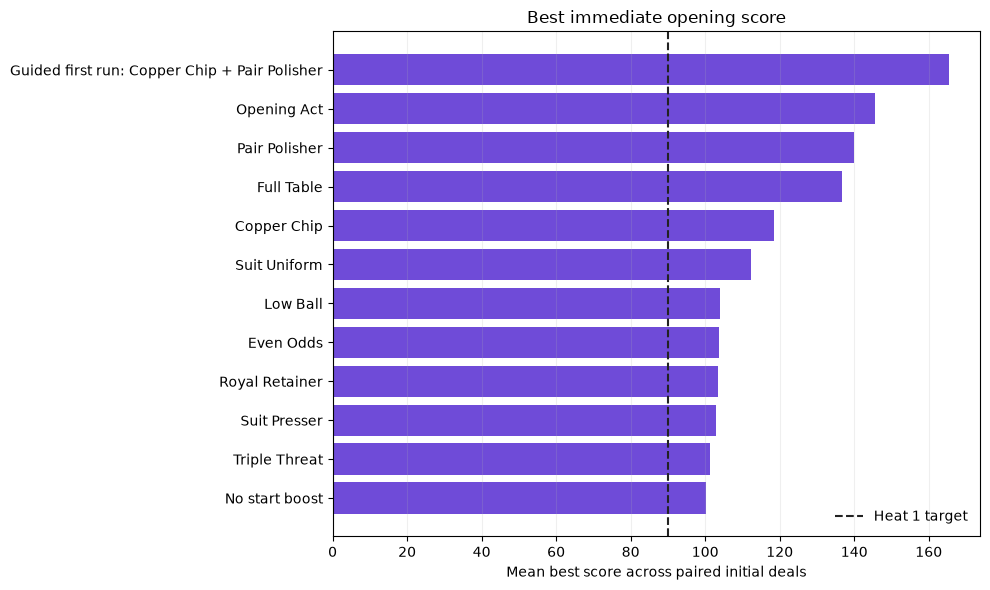

,hand_type,availabilityRate,conditionalAvgBestScore,conditionalMedianBestScore,conditionalP90BestScore
9,Royal Flush,0.02,795.00,795.0,795.0
8,Straight Flush,0.17,622.04,621.0,637.0
7,Four of a Kind,0.61,435.89,435.0,457.0
6,Full House,12.01,336.88,337.0,357.0
5,Flush,13.29,263.34,264.0,275.0
4,Straight,16.90,226.26,226.0,249.0
3,Three of a Kind,17.48,154.23,153.0,169.0
2,Two Pair,62.05,110.30,109.0,126.0
1,Pair,94.90,58.00,58.0,69.0
0,High Card,100.00,17.30,18.0,18.0


In [3]:
plot_open = opening.sort_values("avgBestScore")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_open["name"], plot_open["avgBestScore"], color="#6f4bd8")
ax.axvline(90, color="#222222", linestyle="--", linewidth=1.5, label="Heat 1 target")
ax.set(title="Best immediate opening score", xlabel="Mean best score across paired initial deals", ylabel="")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()

frontier = pd.DataFrame(decision["opening"]["guidedHandFrontier"]).T
frontier.index.name = "hand_type"
frontier = frontier.reset_index().sort_values("conditionalAvgBestScore", ascending=False)
display(frontier)

### Starter strength should be judged by depth as well as rare wins

Heat-12 clears are uncommon in the starter-only shop pool, so average Heats cleared and reach to the boss are more stable screening measures than win rate alone.


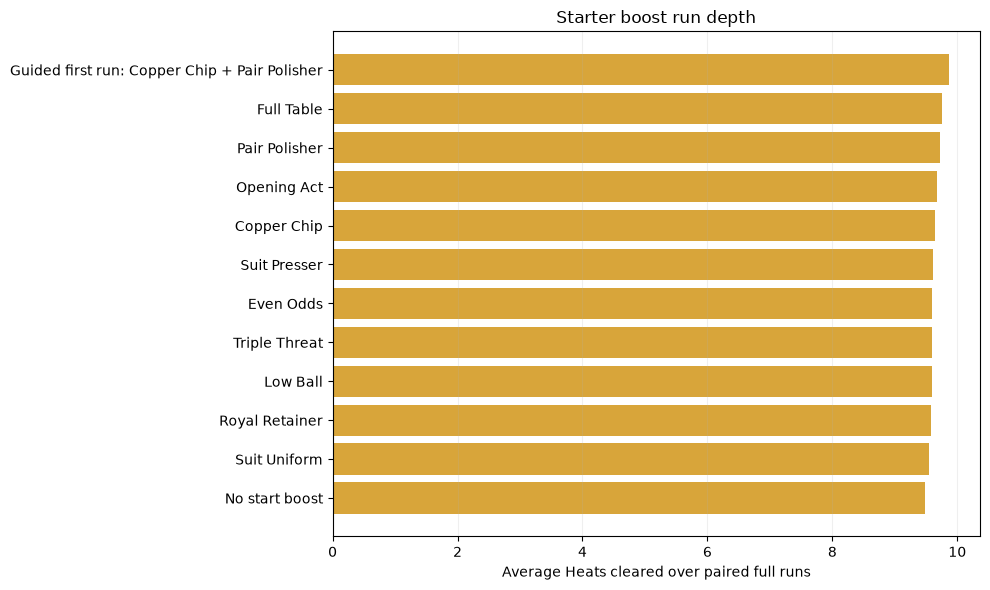

In [4]:
plot_starters = starters.sort_values("avg_cleared")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_starters["starter"], plot_starters["avg_cleared"], color="#d8a53a")
ax.set(title="Starter boost run depth", xlabel="Average Heats cleared over paired full runs", ylabel="")
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()

### Strategy strength and variety are separate axes

All strategies below start with no free Joker. The scatter shows why the strongest build policy is not automatically the most enjoyable: specialist engines can win while compressing most plays into one hand type.


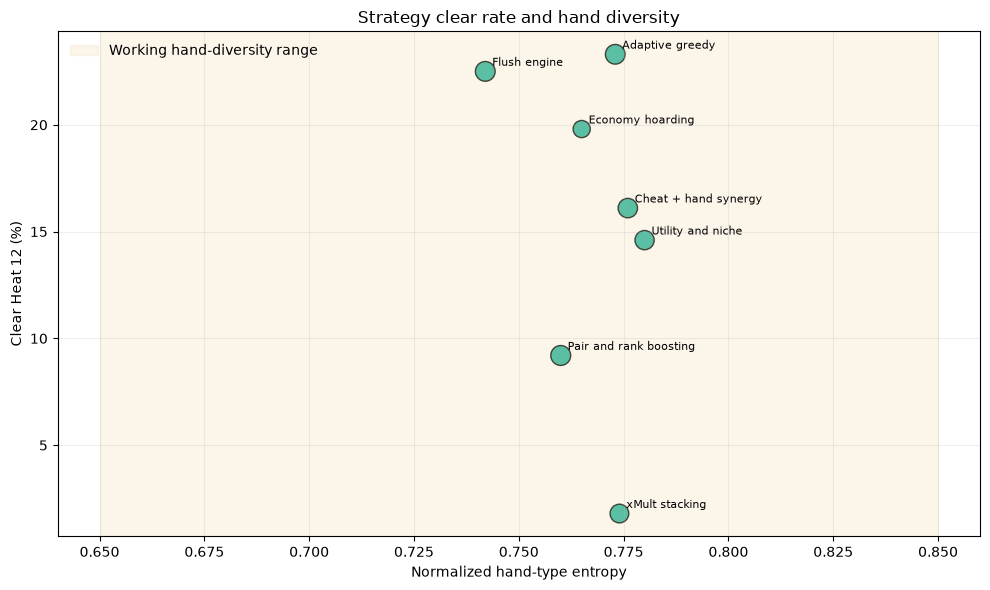

,strategy,win_rate,ci_low,ci_high,avg_cleared,entropy,dominant_hand,dominant_share,active_play_rate,triggers_per_play,notable_play_rate,any_callout_play_rate,final_play_clears,close_clears,build_distance,boss_hazard
0,Adaptive greedy,23.3,20.79,26.02,9.80,0.773,Two Pair,30.85,80.12,2.13,52.24,86.38,25.26,22.28,0.906,55.95
4,Flush engine,22.5,20.02,25.19,9.81,0.742,Flush,33.02,80.97,2.49,52.98,86.12,23.42,23.35,0.878,61.27
5,Economy hoarding,19.8,17.45,22.38,8.82,0.765,Two Pair,30.26,56.39,1.32,48.55,85.51,29.71,25.93,0.935,55.10
1,Cheat + hand synergy,16.1,13.95,18.51,9.49,0.776,Two Pair,31.09,77.81,1.99,51.76,85.52,24.56,23.29,0.893,66.11
3,Utility and niche,14.6,12.55,16.92,9.22,0.780,Two Pair,29.96,75.88,1.81,50.38,85.39,26.51,23.35,0.895,63.32
2,Pair and rank boosting,9.2,7.56,11.15,8.89,0.760,Two Pair,32.38,82.41,3.05,49.65,85.71,25.90,24.99,0.853,68.81
6,xMult stacking,1.8,1.14,2.83,8.81,0.774,Two Pair,31.79,70.78,1.59,49.93,82.58,25.68,22.73,0.899,93.45


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 40 + strategies["active_play_rate"] * 2
ax.scatter(strategies["entropy"], strategies["win_rate"], s=sizes, color="#2db9a3", edgecolor="#1b1b1b", alpha=.85)
for _, row in strategies.iterrows():
    ax.annotate(row["strategy"], (row["entropy"], row["win_rate"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.axvspan(.65, .85, color="#d8a53a", alpha=.10, label="Working hand-diversity range")
ax.set(title="Strategy clear rate and hand diversity", xlabel="Normalized hand-type entropy", ylabel="Clear Heat 12 (%)")
ax.grid(alpha=.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(strategies.sort_values("win_rate", ascending=False)[[
    "strategy", "win_rate", "ci_low", "ci_high", "avg_cleared", "entropy",
    "dominant_hand", "dominant_share", "active_play_rate", "triggers_per_play",
    "notable_play_rate", "any_callout_play_rate", "final_play_clears",
    "close_clears", "build_distance", "boss_hazard"
]])

### Paired uncertainty checks

Wilson intervals describe each arm. Exact paired sign tests below use only discordant win/loss seeds, which is the correct comparison for shared seeds.


In [6]:
def exact_two_sided_binomial(discordant_a: int, discordant_b: int) -> float:
    n = discordant_a + discordant_b
    if n == 0:
        return 1.0
    k = min(discordant_a, discordant_b)
    tail = sum(math.comb(n, i) for i in range(k + 1)) / (2 ** n)
    return min(1.0, 2 * tail)

strategy_pairs = pd.DataFrame(strategy["pairedAgainstBest"])
strategy_pairs["discordant"] = strategy_pairs["bestOnly"] + strategy_pairs["strategyOnly"]
strategy_pairs["paired_p"] = strategy_pairs.apply(
    lambda row: exact_two_sided_binomial(int(row["bestOnly"]), int(row["strategyOnly"])), axis=1
)
starter_pairs = pd.DataFrame(decision["starters"]["pairedAgainstBest"])
starter_pairs["discordant"] = starter_pairs["bestOnly"] + starter_pairs["armOnly"]
starter_pairs["paired_p"] = starter_pairs.apply(
    lambda row: exact_two_sided_binomial(int(row["bestOnly"]), int(row["armOnly"])), axis=1
)
display(strategy_pairs)
display(starter_pairs)

,id,bestId,deltaWinRatePp,bestOnly,strategyOnly,bothWin,bothLose,discordant,paired_p
0,adaptive_greedy,adaptive_greedy,0.0,0,0,233,767,0,1.000000e+00
1,cheat_synergy,adaptive_greedy,-7.2,120,48,113,719,168,2.664142e-08
2,pair_rank,adaptive_greedy,-14.1,188,47,45,720,235,3.673763e-21
3,utility_niche,adaptive_greedy,-8.7,147,60,86,707,207,1.305605e-09
4,flush_engine,adaptive_greedy,-0.8,120,112,113,655,232,6.459173e-01
5,economy_hoarding,adaptive_greedy,-3.5,157,122,76,645,279,4.160536e-02
6,xmult_stacking,adaptive_greedy,-21.5,224,9,9,758,233,7.197667e-55


,id,bestId,deltaWinRatePp,bestOnly,armOnly,bothWin,bothLose,discordant,paired_p
0,none,retainer,-0.3,9,6,8,977,15,0.607239
1,copper,retainer,-0.6,9,3,8,980,12,0.145996
2,presser,retainer,-0.3,4,1,13,982,5,0.375000
3,retainer,retainer,0.0,0,0,17,983,0,1.000000
4,even,retainer,-0.4,5,1,12,982,6,0.218750
5,lowball,retainer,-0.4,7,3,10,980,10,0.343750
6,uniform,retainer,-0.4,12,8,5,975,20,0.503445
7,triple3,retainer,-0.4,10,6,7,977,16,0.454498
8,fulltable,retainer,-0.2,12,10,5,973,22,0.831812
9,polish,retainer,-0.7,12,5,5,978,17,0.143463


### Build identity and fun guardrails

Engine identity means a final build has at least two pieces from one engine and that engine leads the next-best family by at least one piece. These are working design guardrails, not universal laws.


In [7]:
ENGINE_SETS = {
    "pair_rank": {"polish", "trainer", "copper", "presser", "retainer", "even", "acemag", "lowball", "inktrade", "triple3", "number_station", "frequency_meter"},
    "flush_colour": {"flushfund", "uniform", "pocketflush", "color_wash", "prism_lens", "presser", "inktrade", "tailor"},
    "economy": {"dividend", "piggy", "miser", "dumpster"},
    "xmult": {"roller", "lastcall", "couple", "sniper", "boostfiend", "modded", "survivor", "doubledown", "allin", "redline", "master_class", "danger_music", "prism_lens", "glass_joystick"},
    "utility": {"royalscam", "lucky7", "shortcut", "pocketflush", "cheat", "tailor", "collector", "printer", "cleaner", "guillotine"},
}

def has_engine_identity(final_jokers):
    build = set(final_jokers)
    scores = sorted((len(build & members), name) for name, members in ENGINE_SETS.items())[::-1]
    top, second = scores[0][0], scores[1][0]
    return top >= 2 and top - second >= 1

identity_rows = []
for row in strategy["strategies"]:
    identities = [has_engine_identity(outcome["finalJokers"]) for outcome in row["outcomes"]]
    identity_rows.append({"strategy": row["name"], "build_identity_rate": 100 * np.mean(identities)})
identity = pd.DataFrame(identity_rows).sort_values("build_identity_rate", ascending=False)
display(identity)

guardrails = pd.DataFrame([
    ["Hand diversity", "Normalized Shannon entropy", "0.65–0.85 overall"],
    ["Dominant hand", "Largest hand share", "25–45%; up to 60% specialist"],
    ["Build variety", "Mean final-build Jaccard distance", "0.55–0.80"],
    ["Build identity", "Late builds with a clear ≥2-piece engine", "60–85%"],
    ["Joker activity", "Plays with ≥1 scoring Joker event", "55–80% after early game"],
    ["Callout frequency", "Plays at NICE-or-higher / GREAT-or-higher", "Keep major moments uncommon"],
    ["Final-play clears", "Clears scored with one play left", "15–30%"],
    ["Close clears", "Winning margin ≤10% of target", "20–40%"],
    ["Boss hazard", "Heat-12 failures / runs reaching Heat 12", "35–55%"],
    ["Strong-strategy spread", "Best vs other sensible archetypes", "5–15 points"],
], columns=["area", "definition", "working_range"])
display(guardrails)

,strategy,build_identity_rate
2,Pair and rank boosting,91.4
6,xMult stacking,82.5
3,Utility and niche,75.0
4,Flush engine,67.0
0,Adaptive greedy,65.7
1,Cheat + hand synergy,63.7
5,Economy hoarding,52.6


,area,definition,working_range
0,Hand diversity,Normalized Shannon entropy,0.65–0.85 overall
1,Dominant hand,Largest hand share,25–45%; up to 60% specialist
2,Build variety,Mean final-build Jaccard distance,0.55–0.80
3,Build identity,Late builds with a clear ≥2-piece engine,60–85%
4,Joker activity,Plays with ≥1 scoring Joker event,55–80% after early game
5,Callout frequency,Plays at NICE-or-higher / GREAT-or-higher,Keep major moments uncommon
6,Final-play clears,Clears scored with one play left,15–30%
7,Close clears,Winning margin ≤10% of target,20–40%
8,Boss hazard,Heat-12 failures / runs reaching Heat 12,35–55%
9,Strong-strategy spread,Best vs other sensible archetypes,5–15 points


## Takeaways

1. **Teach Pair-or-better, not “play the highest cards.”** The guided opening frontier shows a large score step from High Card to Pair, then another from Pair to Two Pair. A weak High Card should normally be discarded; made hands should normally be banked.
2. **Separate opening burst from full-run value.** Opening Act, Full Table and Pair Polisher can lead the first-deal score table, but the paired 12-Heat comparison determines the durable starter recommendation.
3. **Use the fixed-start strategy result—and treat the top two as tied.** The old report gave different bots different free premium Jokers. This notebook uses no free starter for every strategy, making the comparison substantially cleaner.
4. **Tune toward coherent variety.** A strong engine should be recognisable without forcing one hand type on nearly every play. The useful target is a specialist with clear identity, entropy around 0.65–0.85 and a best-versus-sensible-strategy gap around 5–15 points.
5. **Confirm fun with people.** Closed testers should rate pace and fairness and answer “which Joker just triggered?” Target at least 80% correct trigger recall; simulation cannot verify comprehension.

### Validation status

Both simulation artifacts use the same v6.9.13 source hash, paired deterministic seeds, and report zero data/scoring failures, hook errors and run invariant failures. Conclusions remain **simulation evidence**, not player telemetry or causal proof of enjoyment.
